In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score, 
    confusion_matrix, 
    RocCurveDisplay, 
    precision_score, 
    classification_report
)
from sklearn.ensemble import GradientBoostingClassifier
# from xgboost import XGBoostClassifier
# from imblearn.over_sampling import SMOTE, ADASYN


In [2]:

path = "../Data/telco_customer_churn.csv"
df = pd.read_csv(path).drop('customerID', axis=1)

In [ ]:
# Encoding The Columns. 
yes_no_cols = dict()
for col in df.columns:
    if df[col].nunique() <= 2:
        yes_no_cols[col] = list(df[col].unique())
del yes_no_cols['gender']; del yes_no_cols['SeniorCitizen'] # Not Yes/No Columns. 
for col in yes_no_cols.keys():
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Manual Mappings. 
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No': 0, 'No phone service': -1})

yni = []
for col in df.columns:
    if col in ['Contract', 'MultipleLines', 'InternetService']: continue # Skip these. 
    if df[col].nunique() == 3:
        yni.append(col)
for col in yni:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': -1})

ohe = OneHotEncoder(sparse_output=False)
enc = ohe.fit_transform(df[['InternetService', 'PaymentMethod']]) # Nominal Categorical data. 
temp = pd.DataFrame(enc, columns=ohe.get_feature_names_out())
df = pd.concat([df.drop(columns=['InternetService', 'PaymentMethod']), temp], axis=1)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') # Has NaN values. 
imp = SimpleImputer(strategy='mean')
imp_mean = imp.fit_transform(df[['TotalCharges']])
temp = pd.DataFrame(imp_mean, columns=imp.get_feature_names_out())
df = pd.concat([df.drop(columns=['TotalCharges']), temp], axis=1)


In [14]:
X = df.drop('Churn', axis=1)
y = df['Churn']
lr = LogisticRegression(max_iter=3000)
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=4, random_state=42)

scores_lr = cross_val_score(lr, X, y, cv=5)
scores_dt = cross_val_score(dt, X, y, cv=5)
print(f"lr: {scores_lr.mean()}\ndt: {scores_dt.mean()}")

import warnings
warnings.filterwarnings('ignore')


lr: 0.8040617539841278
dt: 0.7904307334344152


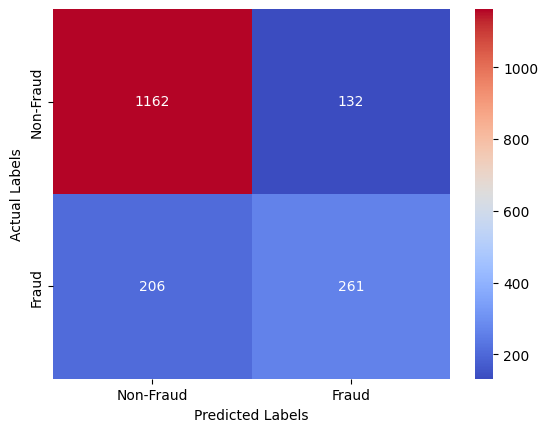

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(data=cm, cmap='coolwarm', annot=True, fmt='d', xticklabels=['Non-Churn', 'Churn'], yticklabels=['Non-Churn', 'Churn'])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()


--- Individual Metrics ---
Precision: 0.8250
Recall:    0.7500
F1 Score:  0.7857
ROC-AUC:   0.9042

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       212
           1       0.82      0.75      0.79        88

    accuracy                           0.88       300
   macro avg       0.86      0.84      0.85       300
weighted avg       0.88      0.88      0.88       300



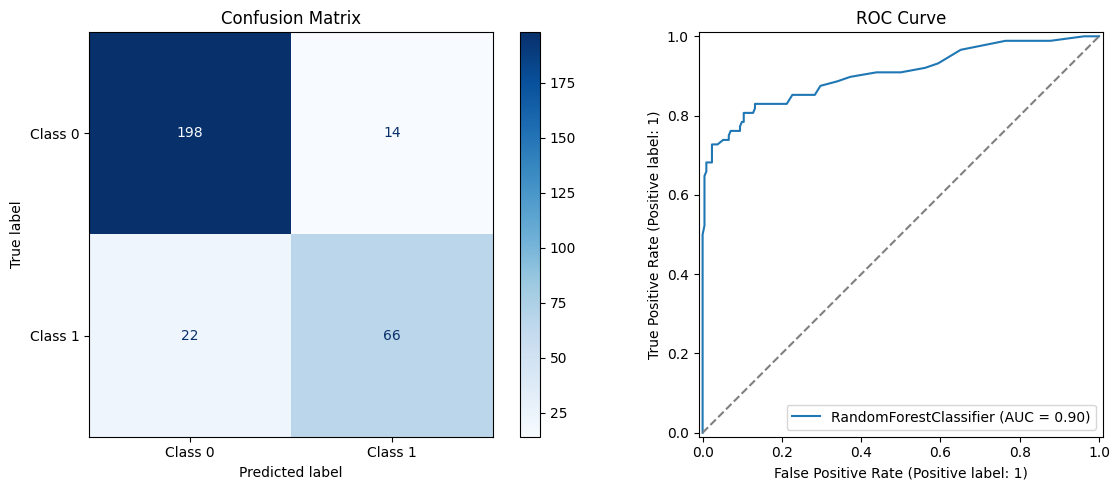

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay,
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report,
    roc_auc_score, 
    RocCurveDisplay
)

# 1. Generate synthetic binary classification data
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.7, 0.3], random_state=42)

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train a basic model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. Generate predictions
# y_pred: Hard class predictions (0 or 1) used for Precision, Recall, F1, and Confusion Matrix
y_pred = model.predict(X_test)

# y_proba: Probability predictions (floats between 0.0 and 1.0) used for ROC-AUC
# We only need the probabilities for the positive class (column index 1)
y_proba = model.predict_proba(X_test)[:, 1]

# ==========================================
# METRICS CALCULATION
# ==========================================

print("--- Individual Metrics ---")
# Setting average='binary' is default for binary classification. 
# Use 'macro' or 'weighted' for multiclass problems.
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

# ROC-AUC requires probabilities, NOT hard predictions!
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}\n")


print("--- Classification Report ---")
# The classification report is a great way to see precision, recall, and F1 for BOTH classes at once.
print(classification_report(y_test, y_pred))


# ==========================================
# VISUALIZATIONS
# ==========================================

# 5. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])

# 6. Visualize the ROC Curve
# Creating a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Confusion Matrix
cm_display.plot(ax=ax1, cmap='Blues')
ax1.set_title("Confusion Matrix")

# Plot ROC Curve
roc_display = RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax2)
ax2.set_title("ROC Curve")
ax2.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guessing') # Adds the 0.5 baseline

plt.tight_layout()
plt.show()